Задание

Самостоятельно напишите нейронную сеть, которая поможет распознавать болезни по симптомам. Используя подготовленную базу, создайте и обучите нейронную сеть, распознающую десять категорий
заболеваний: аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холицестит, эзофагит, энтерит, язва. Добейтесь правильного распознавания 6 и более заболеваний

Сразу обратим внимание датасет небольшой и хороших результатов добится  сложно.

Ссылка на датасет:https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip

In [1]:
import os
import time
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import utils

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SpatialDropout1D,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
)

from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import gdown

%matplotlib inline


#**Получение данных**

In [2]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip'
ARCHIVE_NAME = 'diseases.zip'

gdown.download(DATA_URL, ARCHIVE_NAME, quiet=True)

# Распаковываем данные
with zipfile.ZipFile(ARCHIVE_NAME, 'r') as archive:
    archive.extractall()


# **Получение доступа к данным**

In [3]:
DATA_DIR = Path('dis')     # Каталог с текстовыми файлами
TRAIN_RATIO = 0.8          # Доля текста, которая идет в обучение

CLASS_LIST = []            # Названия заболеваний
text_train = []            # Тексты для обучения
text_test = []             # Тексты для проверки


def read_text(path_to_file):
    """Читает текстовый файл. Если кодировка отличается, пробует запасной вариант."""
    try:
        return path_to_file.read_text(encoding='utf-8')
    except UnicodeDecodeError:
        return path_to_file.read_text(encoding='cp1251')


# Загружаем только txt-файлы из папки с базой
for file_path in sorted(DATA_DIR.iterdir()):
    if file_path.suffix.lower() != '.txt':
        continue

    class_name = file_path.stem

    if class_name not in CLASS_LIST:
        print(f'Добавление класса "{class_name}"')
        CLASS_LIST.append(class_name)

    class_index = CLASS_LIST.index(class_name)
    print(f'Добавление файла "{file_path.name}" в класс "{CLASS_LIST[class_index]}"')

    raw_text = read_text(file_path)
    words = raw_text.replace('\n', ' ').split(' ')
    border = int(len(words) * TRAIN_RATIO)

    text_train.append(' '.join(words[:border]))
    text_test.append(' '.join(words[border:]))


Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"
Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"
Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"


# **Контекстный менеджер**

In [4]:
CLASS_COUNT = len(CLASS_LIST)
print('Количество классов:', CLASS_COUNT)

# Данные прочитаны корректно
for class_index, class_name in enumerate(CLASS_LIST):
    print(f'Класс: {class_name}')
    print(f'  train: {text_train[class_index]}')
    print(f'  test : {text_test[class_index]}')
    print()


class WorkTimer:
    """Контекстный менеджер для замера времени выполнения блока кода."""

    def __enter__(self):
        self.start_time = time.time()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        elapsed = time.time() - self.start_time
        print(f'Время обработки: {elapsed:.2f} с')


Количество классов: 10
Класс: Аппендицит
  train: Резкая боль в животе Повышение температуры Напряженность мышц Тошнота  Острая боль в животе, в том числе и при надавливании Повышение температуры Тошнота Рвота  Тупая боль возле пупка или верхней части живота, которая становится острой, опускаясь в нижнюю правую часть живота. Обычно это первый симптом; Потеря аппетита; Тошнота и/или рвота вскоре после того, как началась боль в животе; Отек брюшной полости; Повышение температуры.  Тупя или острая боль в верхней или нижней части живота, спины или прямой кишки; Болезненное и/или затрудненное мочеиспускание; Рвота Сильные судороги Запор или диарея  Боль в животе, сначала в эпигастральной области или околопупочной области; нередко она имеет нелокализованный характер (боли «по всему животу») Отсутствие аппетита  Тошнота рвота 1-2 кратная  Подъём температуры до 37-38 жидкий стул частые мочеиспускания повышение числа сердечных сокращений повышение давления  Потеря аппетита тошнота Рвота Повышен

# **Задаем параметры**

In [5]:
# Параметры
VOCAB_SIZE = 5000    # Макс размер словаря
WIN_SIZE = 50        # Длина одного текстового окна
WIN_HOP = 5          # Шаг сдвига окна

TOKEN_FILTERS = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters=TOKEN_FILTERS,
    lower=True,
    split=' ',
    char_level=False,
)

# Словарь строится только по обучающей части
tokenizer.fit_on_texts(text_train)

# Текст переводится в последовательности номеров слов
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)


# **Функция для нарезки текстов на окна**

In [6]:
def make_text_windows(sequences, window_size, step):
    """Нарезает последовательности слов на окна и формирует метки классов."""
    x_data = []
    y_data = []

    for class_id, sequence in enumerate(sequences):
        last_start = len(sequence) - window_size + 1

        for start in range(0, last_start, step):
            stop = start + window_size
            x_data.append(sequence[start:stop])
            y_data.append(utils.to_categorical(class_id, CLASS_COUNT))

    return np.array(x_data), np.array(y_data)


# **Формируем выборки**

In [7]:
x_train, y_train = make_text_windows(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = make_text_windows(seq_test, WIN_SIZE, WIN_HOP)

print('Форма x_train:', x_train.shape)
print('Форма x_test :', x_test.shape)


Форма x_train: (1223, 50)
Форма x_test : (161, 50)


# **Создаем и обучаем модель**

In [8]:
def create_disease_model(vocab_size, window_size, class_count):
    """Создает сверточную нейронную сеть для классификации симптомов."""
    network = Sequential([
        Embedding(vocab_size, 64, input_length=window_size),
        SpatialDropout1D(0.3),
        BatchNormalization(),

        Conv1D(64, 5, activation='relu', padding='same'),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(32, 3, activation='relu', padding='same'),
        GlobalMaxPooling1D(),

        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(class_count, activation='softmax'),
    ])

    network.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return network


model = create_disease_model(VOCAB_SIZE, WIN_SIZE, CLASS_COUNT)

with WorkTimer():
    history = model.fit(
        x_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_data=(x_test, y_test),
    )


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - accuracy: 0.1987 - loss: 2.3336 - val_accuracy: 0.1801 - val_loss: 2.2957
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3712 - loss: 1.8852 - val_accuracy: 0.1925 - val_loss: 2.2864
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5879 - loss: 1.3456 - val_accuracy: 0.2174 - val_loss: 2.2607
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8152 - loss: 0.7132 - val_accuracy: 0.3043 - val_loss: 2.1843
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9215 - loss: 0.3324 - val_accuracy: 0.4224 - val_loss: 2.0584
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9599 - loss: 0.1741 - val_accuracy: 0.5528 - val_loss: 1.9212
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9877 - loss: 0.0872 - val_accuracy: 0.6273 - val_loss: 1.7901
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9853 - loss: 0.0728 - val_accuracy: 0.6025 - val_lo

# **Визуализация**

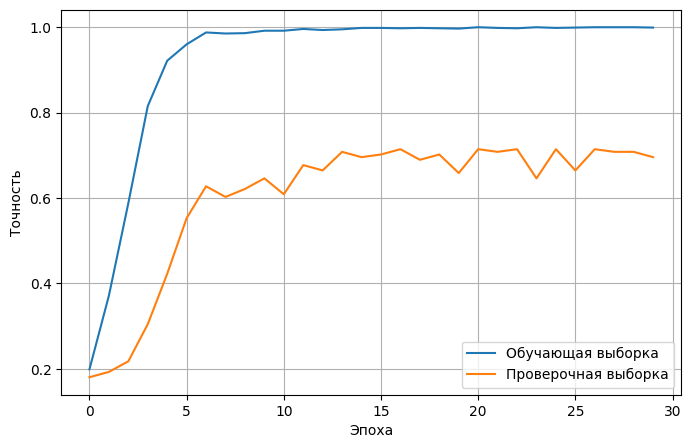

In [9]:
def show_accuracy(history):
    """Строит график точности на обучающей и проверочной выборках."""
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Обучающая выборка')
    plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    plt.grid(True)
    plt.show()


show_accuracy(history)
